In [76]:
import h5py
import numpy as np
import glob
from torch.utils.data import Dataset, DataLoader
import torchcvnn.nn as c_nn
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F

### Test loading

In [34]:
path = "/mnt/i/mridata/brain_multicoil_train_batch_0/multicoil_train/file_brain_AXT2_200_2000057.h5"

In [35]:
with h5py.File(path, "r") as f:
    print("Keys:", list(f.keys()))
    kspace = f["kspace"][:]      # raw k-space
    print("kspace shape:", kspace.shape, "dtype:", kspace.dtype)

    if "reconstruction_rss" in f:
        rss = f["reconstruction_rss"][:]
        print("reconstruction_rss shape:", rss.shape, "dtype:", rss.dtype)

    # look at attributes (metadata)
    attrs = dict(f.attrs)
    print("Attributes:", attrs.keys())

Keys: ['ismrmrd_header', 'kspace', 'reconstruction_rss']
kspace shape: (16, 20, 768, 396) dtype: complex64
reconstruction_rss shape: (16, 384, 384) dtype: float32
Attributes: dict_keys(['acquisition', 'max', 'norm', 'patient_id'])


In [36]:
s = kspace.shape[0] // 2
k_slice = kspace[s]  # [coils, Ny, Nx]
rss_slice = rss[s]   # [Ny, Nx] (if available)

(np.float64(-0.5), np.float64(395.5), np.float64(767.5), np.float64(-0.5))

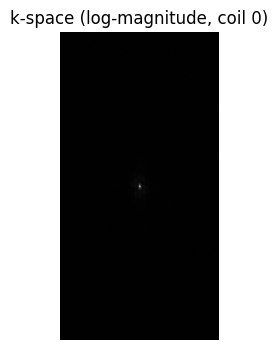

In [37]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("k-space (log-magnitude, coil 0)")
plt.imshow(np.log1p(np.abs(k_slice[0])), cmap='gray')
plt.axis('off')

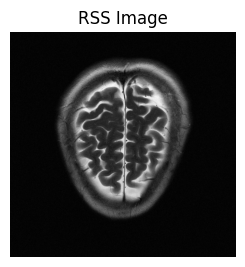

In [38]:
if rss is not None:
    plt.subplot(1,2,2)
    plt.title("RSS Image")
    plt.imshow(rss_slice, cmap='gray')
    plt.axis('off')
else:
    img = np.fft.ifft2(k_slice, norm='ortho')
    img_rss = np.sqrt(np.sum(np.abs(img)**2, axis=0))
    plt.subplot(1,2,2)
    plt.title("RSS Image (computed)")
    plt.imshow(img_rss, cmap='gray')
    plt.axis('off')

plt.show()

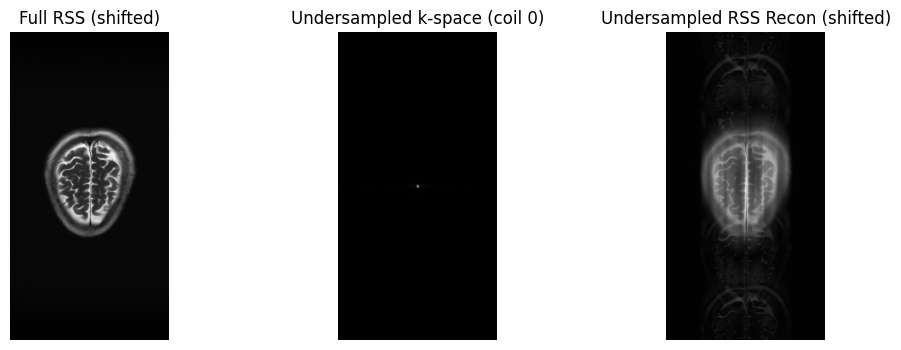

In [40]:
def simple_mask(Ny, accel=4):
    mask = np.zeros(Ny, dtype=np.float32)
    mask[::accel] = 1.0
    # keep some low-frequency center lines
    center = Ny // 2
    mask[center-4:center+4] = 1.0
    return mask

Ny, Nx = k_slice.shape[1], k_slice.shape[2]
mask = simple_mask(Ny, accel=4)[:, None]   # [Ny,1]
k_und = k_slice * mask                     # [coils,Ny,Nx]


# Full recon in image space
img_full = np.fft.ifft2(k_slice, norm="ortho")        # [coils,Ny,Nx]
img_full_rss = np.sqrt(np.sum(np.abs(img_full)**2, axis=0))  # [Ny,Nx]

# SHIFT for visualization
img_full_rss_disp = np.fft.fftshift(img_full_rss)  


# IFFT in image space
img_und = np.fft.ifft2(k_und, norm="ortho")          # [coils,Ny,Nx]
img_und_rss = np.sqrt(np.sum(np.abs(img_und)**2, axis=0))   # [Ny,Nx]

# fftshift only for display
img_und_rss_disp  = np.fft.fftshift(img_und_rss)
img_full_rss_disp = np.fft.fftshift(img_full_rss)   # from before

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.title("Full RSS (shifted)")
plt.imshow(img_full_rss_disp, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Undersampled k-space (coil 0)")
plt.imshow(np.log1p(np.abs(k_und[0])), cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Undersampled RSS Recon (shifted)")
plt.imshow(img_und_rss_disp, cmap="gray")
plt.axis("off")
plt.show()


In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [42]:
def rss_combine(img_mc):
    """
    Root-sum-of-squares coil combination.
    img_mc: [num_coils, Ny, Nx], complex
    returns: [Ny, Nx], real
    """
    return torch.sqrt((img_mc.abs() ** 2).sum(dim=0) + 1e-8)

In [62]:
def simple_mask(Ny, accel=4, device="cpu"):
    mask = torch.zeros(Ny, dtype=torch.float32, device=device)
    mask[::accel] = 1.0
    center = Ny // 2
    mask[center-4:center+4] = 1.0
    return mask


### For bulk dataset in the folder

In [44]:
class FastMRIDataset(Dataset):
    def __init__(self, h5_paths, accel=4, max_slices=None):
        self.paths = h5_paths
        self.accel = accel

        self.samples = []  # list of (path, slice_idx)
        for p in self.paths:
            with h5py.File(p, "r") as f:
                num_slices = f["kspace"].shape[0]
            for s in range(num_slices):
                self.samples.append((p, s))
                if max_slices is not None and len(self.samples) >= max_slices:
                    break
            if max_slices is not None and len(self.samples) >= max_slices:
                break

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, s = self.samples[idx]
        with h5py.File(path, "r") as f:
            kspace = f["kspace"][s]  # [num_coils, Ny, Nx], complex64
            kspace = torch.from_numpy(kspace)      # complex64

            # simple 1D undersampling mask along phase-encode (Ny)
            Ny, Nx = kspace.shape[-2], kspace.shape[-1]
            mask = simple_mask(Ny, accel=self.accel).to(kspace.device)
            mask = mask[:, None]                 # [Ny,1], broadcast over Nx
            kspace_und = kspace * mask          # [coils, Ny, Nx]

        # IFFT2 coil-wise: k-space -> image domain
        img_full_mc = torch.fft.ifft2(kspace, norm="ortho")      # [coils,Ny,Nx]
        img_und_mc  = torch.fft.ifft2(kspace_und, norm="ortho")  # [coils,Ny,Nx]

        # Coil combine: RSS magnitude image as target (Y)
        img_full_rss = rss_combine(img_full_mc)   # [Ny,Nx], real

        # For complex model input, you can either:
        # A) use coil-combined complex input (e.g., sum of coils)
        img_und_comb = img_und_mc.sum(dim=0)      # [Ny,Nx], complex

        # add channel dim for Conv2d / complex Conv2d: [1,H,W]
        X_complex = img_und_comb.unsqueeze(0)     # complex [1,H,W]
        Y_target = img_full_rss.unsqueeze(0)      # real [1,H,W]

        return X_complex, Y_target


### For single files

In [45]:
class SingleFastMRIDataset(Dataset):
    def __init__(self, path, accel=4, max_slices=None):
        self.path = path
        self.accel = accel

        # Just count slices in this file
        with h5py.File(self.path, "r") as f:
            num_slices = f["kspace"].shape[0]

        self.slice_indices = list(range(num_slices))
        if max_slices is not None:
            self.slice_indices = self.slice_indices[:max_slices]

    def __len__(self):
        return len(self.slice_indices)

    def __getitem__(self, idx):
        s = self.slice_indices[idx]
        with h5py.File(self.path, "r") as f:
            kspace = f["kspace"][s]   # [num_coils, Ny, Nx] or [Ny,Nx]
            kspace = torch.from_numpy(kspace)      # complex64

        # ----- simple mask along phase-encode dim -----
        Ny, Nx = kspace.shape[-2], kspace.shape[-1]
        mask = simple_mask(Ny, accel=self.accel).to(kspace.device)
        mask = mask[:, None]           # [Ny,1]
        kspace_und = kspace * mask     # same shape as kspace

        # ----- go to image domain -----
        img_full = torch.fft.ifft2(kspace, norm="ortho")      # complex
        img_und  = torch.fft.ifft2(kspace_und, norm="ortho")  # complex

        # if multicoil: coil combine with RSS
        if img_full.ndim == 3:  # [coils,Ny,Nx]
            img_full_rss = rss_combine(img_full)  # [Ny,Nx], real
            # simple coil-combined complex input (sum of coils)
            img_und_comb = img_und.sum(dim=0)     # [Ny,Nx], complex
        else:  # single-coil [Ny,Nx]
            img_full_rss = img_full.abs()
            img_und_comb = img_und

        X_complex = img_und_comb.unsqueeze(0)   # [1,H,W], complex
        Y_target  = img_full_rss.unsqueeze(0)   # [1,H,W], float

        return X_complex, Y_target


In [46]:
# train_file = sorted(glob("multicoil_train/file_brain_*.h5"))
# val_file   = sorted(glob("multicoil_val/file_brain_*.h5"))  

# train_ds = FastMRIDataset(train_files, accel=4, max_slices=2000)
# val_ds   = FastMRIDataset(val_files,   accel=4, max_slices=500)


train_path = "/mnt/i/mridata/brain_multicoil_train_batch_0/multicoil_train/file_brain_AXT2_200_2000057.h5"
val_path   = "/mnt/i/mridata/brain_multicoil_val_batch_0/multicoil_val/file_brain_AXT2_200_2000022.h5"

train_ds = SingleFastMRIDataset(train_path, accel=4, max_slices=2000)
val_ds   = SingleFastMRIDataset(val_path,   accel=4, max_slices=500)

cv_train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=4, pin_memory=True)
cv_val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False, num_workers=4, pin_memory=True)

x0, y0 = next(iter(cv_train_loader))
print("X_complex batch:", x0.shape, x0.dtype)  # [B,1,H,W], complex
print("Y_target batch:", y0.shape, y0.dtype)   # [B,1,H,W], float32


X_complex batch: torch.Size([4, 1, 768, 396]) torch.complex64
Y_target batch: torch.Size([4, 1, 768, 396]) torch.float32


In [47]:
def get_complex_activation(name: str):
    name = name.lower()
    if name == "modrelu":
        return c_nn.modReLU()
    elif name == "zrelu":
        return c_nn.zReLU()
    elif name == "cardioid":
        return c_nn.Cardioid()
    elif name == "c_relu":
        return c_nn.CReLU()
    elif name == "c_sigmoid":
        return c_nn.CSigmoid()
    elif name == "c_tanh":
        return c_nn.CTanh()
    elif name == "c_elu":
        return c_nn.CELU()
    elif name == "c_gelu":
        return c_nn.CGELU()
    else:
        return nn.Identity()

In [129]:
class ComplexMRIUNetSmall(nn.Module):
    def __init__(self, act_name="cardioid"):
        super().__init__()
        act = get_complex_activation(act_name)

        # Encoder blocks - Use PyTorch's nn.Conv2d (supports complex!)
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(16),
            act,
            nn.Conv2d(16, 16, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(16),
            act,
        )
        self.pool1 = c_nn.AvgPool2d(kernel_size=2, stride=2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(32),
            act,
            nn.Conv2d(32, 32, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(32),
            act,
        )
        self.pool2 = c_nn.AvgPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(64),
            act,
            nn.Conv2d(64, 64, kernel_size=3, padding=1, dtype=torch.complex64),
            c_nn.BatchNorm2d(64),
            act,
        )

        # Decoder blocks
        self.up2 = c_nn.ConvTranspose2d(
            64, 32, kernel_size=3, stride=2, padding=1, output_padding=1
        )
        self.dec2 = nn.Sequential(
            c_nn.BatchNorm2d(32),
            act,
            nn.Conv2d(64, 32, kernel_size=3, padding=1, dtype=torch.complex64),  # 32+32=64
            c_nn.BatchNorm2d(32),
            act,
        )

        self.up1 = c_nn.ConvTranspose2d(
            32, 16, kernel_size=3, stride=2, padding=1, output_padding=1
        )
        self.dec1 = nn.Sequential(
            c_nn.BatchNorm2d(16),
            act,
            nn.Conv2d(32, 16, kernel_size=3, padding=1, dtype=torch.complex64),  # 16+16=32
            c_nn.BatchNorm2d(16),
            act,
        )

        # Final conv to 1 channel
        self.out_conv = nn.Conv2d(16, 1, kernel_size=3, padding=1, dtype=torch.complex64)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # Bottleneck
        b = self.bottleneck(p2)

        # Decoder
        u2 = self.up2(b)
        u2 = torch.cat([u2, e2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.up1(d2)
        u1 = torch.cat([u1, e1], dim=1)
        d1 = self.dec1(u1)

        out = self.out_conv(d1)
        return out

In [131]:
def visualize_reconstruction(model, val_loader, num_samples=3, tag="modrelu"):
    model.eval()
    with torch.no_grad():
        x, y = next(iter(val_loader))
        x = x.to(device)      # [B,1,H,W] complex
        y = y.to(device)      # [B,1,H,W] real

        y_hat = model(x)      # [B,1,H,W] complex

        x_cpu = x.cpu()
        y_cpu = y.cpu()
        y_hat_cpu = y_hat.cpu()

        def norm_img(img):
            vmin, vmax = img.min(), img.max()
            if vmax > vmin:
                return (img - vmin) / (vmax - vmin)
            else:
                return np.zeros_like(img)

        fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
        if num_samples == 1:
            axes = axes.reshape(1, -1)

        for i in range(num_samples):
            in_mag   = np.fft.fftshift(x_cpu[i,0].abs().numpy())
            tgt_mag  = np.fft.fftshift(y_cpu[i,0].numpy())
            pred_mag = np.fft.fftshift(y_hat_cpu[i,0].abs().numpy())

            print(f"Sample {i}: in[{in_mag.min():.3e},{in_mag.max():.3e}] "
                  f"tgt[{tgt_mag.min():.3e},{tgt_mag.max():.3e}] "
                  f"pred[{pred_mag.min():.3e},{pred_mag.max():.3e}]")

            in_disp   = norm_img(np.log1p(in_mag))
            tgt_disp  = norm_img(np.log1p(tgt_mag))
            pred_disp = norm_img(np.log1p(pred_mag))

            axes[i,0].imshow(in_disp, cmap="gray")
            axes[i,0].set_title("Input (fftshift)")
            axes[i,0].axis("off")

            axes[i,1].imshow(tgt_disp, cmap="gray")
            axes[i,1].set_title("Target (fftshift)")
            axes[i,1].axis("off")

            axes[i,2].imshow(pred_disp, cmap="gray")
            axes[i,2].set_title("Prediction (fftshift)")
            axes[i,2].axis("off")

        print("target mean/std:", y.mean().item(), y.std().item())
        print("pred abs mean/std:", y_hat.abs().mean().item(), y_hat.abs().std().item())

        plt.suptitle(f"Reconstruction – {tag}")
        plt.tight_layout()
        plt.show()


In [132]:
def calculate_psnr(pred, target, max_val=1.0):
    """Simple PSNR calculation"""
    mse = np.mean((pred - target) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(max_val / np.sqrt(mse))

In [133]:
def mag_mse(pred, target):
    diff = pred.abs() - target
    return (diff ** 2).mean()

In [134]:
def train_one_epoch(model, loader, optimizer, epoch, tag="cardioid"):
    model.train()
    total_loss, total = 0.0, 0
    for x, y in tqdm(loader, desc=f"[{tag}] Train {epoch}", leave=False):
        x = x.to(device)   # complex
        y = y.to(device)   # real

        optimizer.zero_grad()
        y_hat = model(x)   # complex

        # print("x:", x.shape, "y:", y.shape)
        # y_hat = model(x)
        # print("y_hat:", y_hat.shape)
        # break  # temporary, to see one batch

        loss = mag_mse(y_hat, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total += x.size(0)

        # NEEDTTO ADD LOGGING LATER
        # with torch.no_grad():
        #     grad_norm = torch.sqrt(sum((p.grad**2).sum() for p in model.parameters()))

    print(f"[{tag}] Epoch {epoch} | loss={total_loss/total:.6f}")

In [135]:
def evaluate(model, loader, tag="cardioid"):
    model.eval()
    total_loss, total = 0.0, 0
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"[{tag}] Eval", leave=False):
            x = x.to(device)
            y = y.to(device)
            y_hat = model(x)
            loss = mag_mse(y_hat, y)
            total_loss += loss.item() * x.size(0)
            total += x.size(0)
    avg_loss = total_loss / total
    print(f"[{tag}] Val | loss={avg_loss:.6f}")
    return avg_loss

In [136]:
def complex_to_two_channels(x):
    # x: [B,1,H,W] complex
    xr = torch.view_as_real(x)        # [B,1,H,W,2]
    xr = xr.squeeze(1).permute(0, 3, 1, 2)  # [B,2,H,W]
    return xr.float()



=== Testing activation: modrelu ===


[modrelu] Epoch 1 | loss=0.268764


[modrelu] Val | loss=0.002995


[modrelu] Epoch 2 | loss=0.052272


[modrelu] Val | loss=0.001010


Sample 0: in[4.469e-08,2.943e-04] tgt[1.001e-04,6.651e-04] pred[4.202e-03,8.705e-02]
Sample 1: in[5.858e-08,2.976e-04] tgt[1.001e-04,5.867e-04] pred[4.200e-03,8.706e-02]
Sample 2: in[4.485e-08,3.122e-04] tgt[1.001e-04,6.697e-04] pred[4.196e-03,8.705e-02]
target mean/std: 0.00011980719864368439 4.876314051216468e-05
pred abs mean/std: 0.03001754730939865 0.010776512324810028


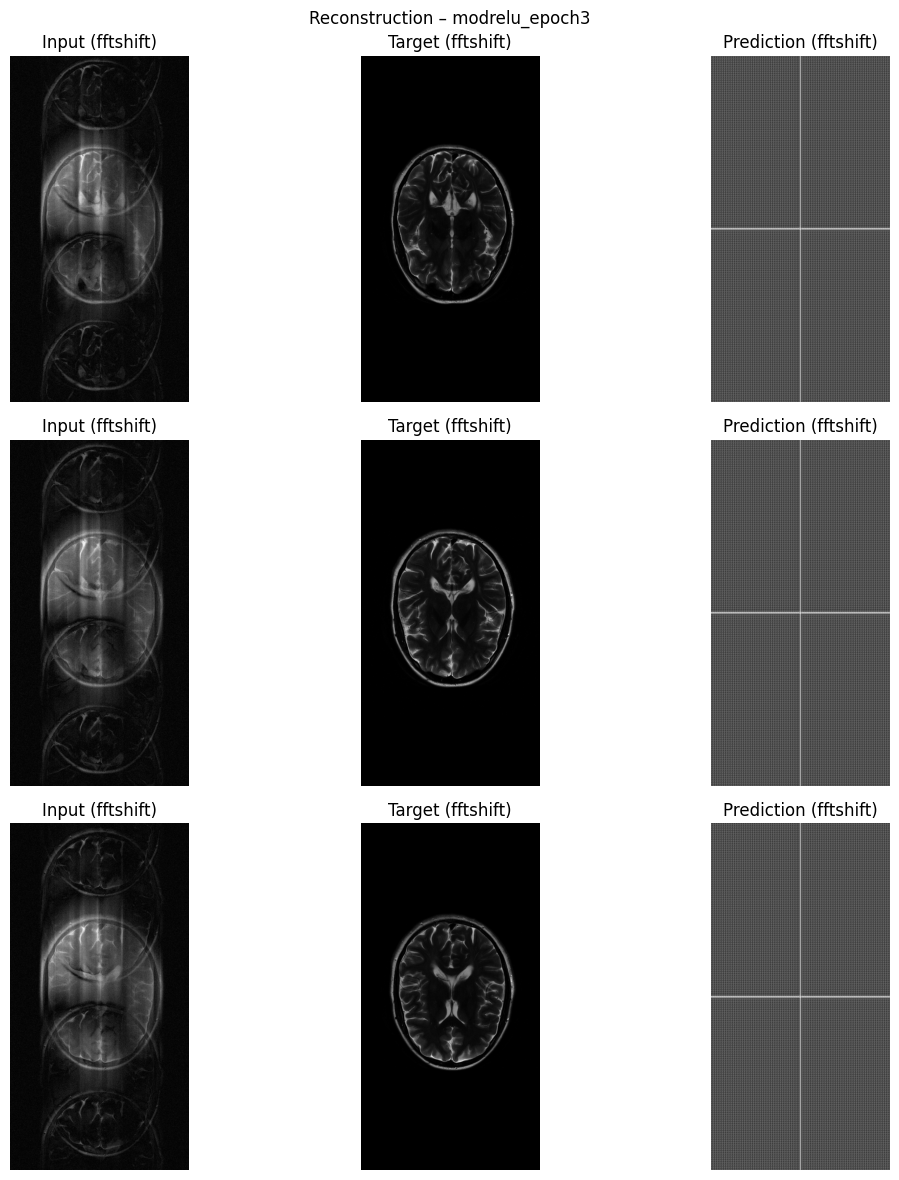

In [137]:
activations_to_test = ["modrelu", "zrelu", "cardioid", "c_relu", "c_sigmoid", "c_tanh", "c_elu", "c_gelu"]

for act_name in activations_to_test:
    print(f"\n=== Testing activation: {act_name} ===")
    model = ComplexMRIUNetSmall(act_name=act_name).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(1, 3):
        train_one_epoch(model, cv_train_loader, optimizer, epoch, act_name)
        evaluate(model, cv_val_loader, act_name)

    visualize_reconstruction(model, cv_val_loader, num_samples=3, tag=f"{act_name}_epoch{epoch+1}")
    
    break #just want to train for modrelu right now

In [109]:
print("Available layers in torchcvnn.nn:")
for name in dir(c_nn):
    if not name.startswith('_'):
        print(f"  - {name}")

Available layers in torchcvnn.nn:
  - AdaptiveAvgPool2d
  - AvgPool2d
  - BatchNorm1d
  - BatchNorm2d
  - CCELU
  - CELU
  - CGELU
  - CPReLU
  - CReLU
  - CSigmoid
  - CTanh
  - Cardioid
  - ComplexMSELoss
  - ConvTranspose2d
  - Dropout
  - Dropout2d
  - LayerNorm
  - MaxPool2d
  - Mod
  - MultiheadAttention
  - RMSNorm
  - Transformer
  - TransformerDecoderLayer
  - TransformerEncoder
  - TransformerEncoderLayer
  - Upsample
  - ViT
  - ViTLayer
  - activation
  - batchnorm
  - conv
  - dropout
  - functional
  - init
  - initialization
  - loss
  - modReLU
  - modules
  - normalization
  - pooling
  - transformer
  - upsampling
  - vit
  - zAbsReLU
  - zLeakyReLU
  - zReLU


In [ ]:
for x, y in real_train_loader:
    x = complex_to_two_channels(x).to(device)
    y = y.to(device)  # [B,1,H,W]
    # maybe use y as magnitude target, or flatten to regression/classification as needed
